In [1]:
import numpy as np
import matplotlib.pyplot as plt
from safety_formation.control_law.cbf import DecentralizedCBF

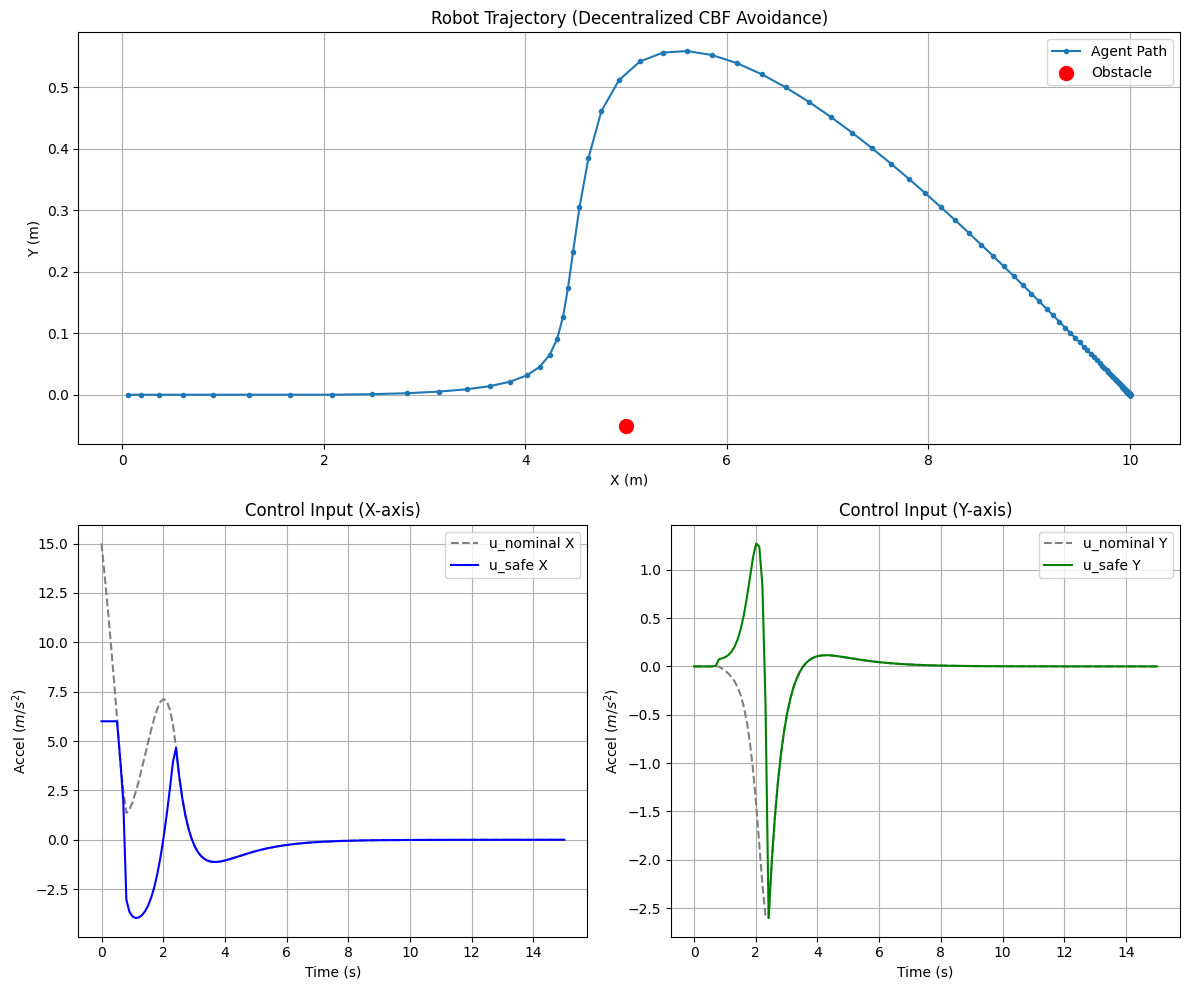

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Configuration ---
dt = 0.1
T = 15.0 
steps = int(T / dt)
gamma = 1.0     # CBF relaxation parameter
d_min = 0.5     # Minimum safety distance (m)

# Agent and Obstacle Initial States: [x, y, vx, vy]
x_agent = np.array([0.0, 0.0, 0.0, 0.0]) 
x_obs = np.array([5.0, -0.05, 0.0, 0.0]) # Static obstacle slightly off-center
x_target = np.array([10.0, 0.0, 0.0, 0.0])

alpha_agent = 6.0 # Max acceleration for the agent
alpha_obs = 0.0   # Static obstacle has no acceleration capability

# Data logging
history = []
u_hat_history = []
u_safe_history = []

# Initialize the Decentralized CBF filter
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

for k in range(steps):
    # 1. Compute Nominal Control (PD Controller)
    # Drives the agent toward target while damping oscillations
    u_hat = -1.5 * (x_agent[0:2] - x_target[0:2]) - 2.5 * x_agent[2:4]
    
    # 2. Mock Agent Data for the Filter
    # In decentralized mode, the filter needs the state of neighbors
    class MockAgent:
        def __init__(self, pos, vel, alpha, id):
            self.pos = pos
            self.vel = vel
            self.alpha = alpha
            self.id = id

    a1 = MockAgent(x_agent[0:2], x_agent[2:4], alpha_agent, 1)
    a2 = MockAgent(x_obs[0:2], x_obs[2:4], alpha_obs, 2)
    
    # All agents in the environment (needed for neighbor lookup)
    all_agents = {1: a1, 2: a2}
    neighbor_list = [2] # Agent 1 detects Obstacle 2
    
    # 3. Filter via Decentralized CBF
    # Only solves the QP for agent 1 locally
    u_nom_i = u_hat.reshape(2, 1)
    u_apply = cbf_filter.compute_safe_control(a1, 1, all_agents, neighbor_list, u_nom_i)
    
    # Handle QP failure (fallback to zero acceleration/braking)
    if u_apply is not None:
        u_apply = u_apply.flatten()
    else:
        u_apply = np.array([0.0, 0.0])

    # Log control inputs
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # 4. Update Physics (Euler Integration)
    # v = v + a*dt, p = p + v*dt
    x_agent[2:4] += u_apply * dt
    x_agent[0:2] += x_agent[2:4] * dt
    history.append(x_agent.copy())

# --- Visualization ---
history = np.array(history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
time = np.linspace(0, T, steps)



fig = plt.figure(figsize=(12, 10))

# Plot Trajectory
ax1 = plt.subplot(2, 1, 1)
ax1.plot(history[:, 0], history[:, 1], '-o', markersize=3, label='Agent Path')
ax1.scatter([x_obs[0]], [x_obs[1]], color='red', s=100, label='Obstacle', zorder=5)
ax1.set_title("Robot Trajectory (Decentralized CBF Avoidance)")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)")
ax1.legend(); ax1.grid(True)

# Plot Control Input X
ax2 = plt.subplot(2, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nominal X')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe X')
ax2.set_title("Control Input (X-axis)")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Accel ($m/s^2$)")
ax2.legend(); ax2.grid(True)

# Plot Control Input Y
ax3 = plt.subplot(2, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nominal Y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe Y')
ax3.set_title("Control Input (Y-axis)")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("Accel ($m/s^2$)")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

Agent 0 QP Failed!
Agent 5 QP Failed!
Agent 10 QP Failed!
Agent 15 QP Failed!
Agent 0 QP Failed!
Agent 5 QP Failed!
Agent 10 QP Failed!
Agent 15 QP Failed!
Agent 0 QP Failed!
Agent 5 QP Failed!
Agent 10 QP Failed!
Agent 15 QP Failed!
Agent 0 QP Failed!
Agent 5 QP Failed!
Agent 10 QP Failed!
Agent 15 QP Failed!
Agent 0 QP Failed!
Agent 5 QP Failed!
Agent 10 QP Failed!
Agent 15 QP Failed!
Agent 1 QP Failed!
Agent 4 QP Failed!
Agent 12 QP Failed!
Agent 13 QP Failed!
Agent 1 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 4 QP Failed!
Agent 6 QP Failed!
Agent 7 QP Failed!
Agent 8 QP Failed!
Agent 9 QP Failed!
Agent 11 QP Failed!
Agent 12 QP Failed!
Agent 13 QP Failed!
Agent 14 QP Failed!
Agent 16 QP Failed!
Agent 17 QP Failed!
Agent 18 QP Failed!
Agent 19 QP Failed!
Agent 1 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 4 QP Failed!
Agent 6 QP Failed!
Agent 7 QP Failed!
Agent 8 QP Failed!
Agent 9 QP Failed!
Agent 11 QP Failed!
Agent 12 QP Failed!
Agent 13 QP Failed!
Agent 14

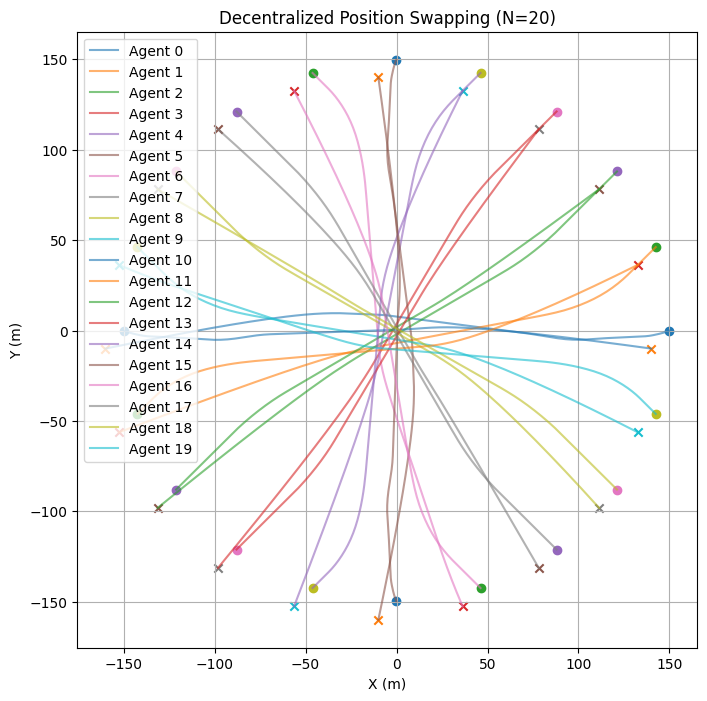

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Configuration ---
N = 20               # Number of agents
R_circle = 150      # Circle radius
dt = 0.1
T_max = 20          # Simulation time
gamma = 0.01         # CBF relaxation (higher = tighter avoidance)
d_min = 20.0        # Safety distance (Ds)
k1, k2 = 1.0, 2.0   # PD controller gains

# --- Agent Class for Simulation ---
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = pos
        self.vel = np.zeros(2)
        self.target = target
        self.alpha = 20.0  # Max acceleration limit

# --- Initialize Agents ---
agents_dict = {}
for i in range(N):
    angle = 2 * np.pi * i / N
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)])
    target = -pos - 10# Goal is exactly on the opposite side
    agents_dict[i] = AgentObj(i, pos, target)

# Initialize the Decentralized CBF filter
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

# Data logging
history = [[] for _ in range(N)]

# --- Simulation Loop ---
for t in range(int(T_max/dt)):
    # In decentralized control, each agent performs its own computation
    u_safe_commands = {}
    
    for i in range(N):
        current_agent = agents_dict[i]
        
        # 1. Compute Nominal Control (Nominal "Wish")
        u_nom_i = -k1 * (current_agent.pos - current_agent.target) - k2 * current_agent.vel
        u_nom_i = u_nom_i.reshape(2, 1)
        
        # 2. Identify Neighbors (In this case, all other agents)
        neighbor_list = [j for j in range(N) if i != j]
        
        # 3. Apply Decentralized CBF Filter
        # This solves a local 2x2 QP for Agent i
        u_safe_i = cbf_filter.compute_safe_control(
            current_agent, i, agents_dict, neighbor_list, u_nom_i
        )
        
        if u_safe_i is not None:
            u_safe_commands[i] = u_safe_i.flatten()
        else:
            u_safe_commands[i] = np.zeros(2) # Fallback to stop

    # 4. Physical Update (Sync step: apply all movements after calculation)
    for i in range(N):
        ag = agents_dict[i]
        ag.vel += u_safe_commands[i] * dt
        ag.pos += ag.vel * dt
        history[i].append(ag.pos.copy())

# --- Plotting Results ---
plt.figure(figsize=(8,8))
for i in range(N):
    traj = np.array(history[i])
    plt.plot(traj[:,0], traj[:,1], alpha=0.6, label=f'Agent {i}')
    plt.scatter(traj[0,0], traj[0,1], marker='o') # Start
    plt.scatter(traj[-1,0], traj[-1,1], marker='x') # End

plt.title(f"Decentralized Position Swapping (N={N})")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

# --- 1. Simulation Configuration ---
N = 5              # Number of agents
R_circle = 150      # Radius
dt = 0.1            # Time step
T_max = 15          # Increased time to allow agents to reach targets
gamma = 0.01         # Lower gamma for smoother decentralized response
d_min = 20.0        # Safety distance (Ds)
k1, k2 = 1.0, 2.0   # PD gains

# --- 2. Define Agent Class (Compatible with DecentralizedCBF) ---
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = np.array(pos, dtype=float)
        self.vel = np.zeros(2, dtype=float)
        self.target = np.array(target, dtype=float)
        self.alpha = 20.0  # Max acceleration

# --- 3. Initialize State ---
agents_dict = {} # Using a dict for easier ID lookup in decentralized mode
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)], dtype=float)
    target = -pos -10# Perfect swap
    agents_dict[i] = AgentObj(i, pos, target)

# Initialize the DECENTRALIZED filter
cbf_filter = DecentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- 4. Setup Plotting ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Decentralized CBF: Position Swapping Animation")

for ag in agents_dict.values():
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# --- 5. Decentralized Update Function ---
def update(frame):
    global agents_dict, history
    
    u_safe_commands = {}

    # Each agent computes its own control independently
    for i in range(N):
        ag = agents_dict[i]
        
        # a. Local Nominal Control (Wish)
        u_nom_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_i = u_nom_i.reshape(2, 1)
        
        # b. Identify Neighbors (In this case, all others)
        neighbor_list = [j for j in range(N) if i != j]
        
        # c. Local CBF Filter (Solves a 2x2 QP per agent)
        u_safe_i = cbf_filter.compute_safe_control(ag, i, agents_dict, neighbor_list, u_nom_i)
        # u_safe_i = u_nom_i
        
        if u_safe_i is not None:
            u_safe_commands[i] = u_safe_i.flatten()
        else:
            u_safe_commands[i] = np.array([0, 0]) # Fallback if QP fails

    # d. Synchronous Physics Update
    for i in range(N):
        ag = agents_dict[i]
        ag.vel += u_safe_commands[i] * dt
        ag.pos += ag.vel * dt
        
        history[i].append(ag.pos.copy())
        traj = np.array(history[i])
        points[i].set_data([ag.pos[0]], [ag.pos[1]])
        trails[i].set_data(traj[:, 0], traj[:, 1])

    info_text.set_text(f"Time: {frame*dt:.1f}s | Decentralized Mode")
    return points + trails + [info_text]

# --- 6. Rendering ---
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

print("Rendering decentralized_cbf_validation.mp4...")
try:
    writer = FFMpegWriter(fps=int(1/dt), bitrate=2000)
    ani.save("decentralized_cbf_validation.mp4", writer=writer)
    print("Success! Decentralized validation video created.")
except Exception as e:
    print(f"Error: {e}")

plt.close(fig)

Rendering decentralized_cbf_validation.mp4...
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Agent 3 QP Failed!
Agent 0 QP Failed!
Agent 2 QP Failed!
Success! Decentralized validation video created.
